2.19.0
Epoch 1/20


C:\Users\panda\AppData\Local\Temp\ipykernel_12088\1971787135.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.replace('', 0, inplace=True)
C:\Users\panda\AppData\Local\Temp\ipykernel_12088\1971787135.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({
C:\Users\panda\AppData\Local\Temp\ipykernel_12088\1971787135.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.repl

177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6649 - loss: 0.6297 - val_accuracy: 0.6599 - val_loss: 0.6185
Epoch 2/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6751 - loss: 0.5908 - val_accuracy: 0.6630 - val_loss: 0.6240
Epoch 3/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7002 - loss: 0.5747 - val_accuracy: 0.6579 - val_loss: 0.6168
Epoch 4/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6973 - loss: 0.5762 - val_accuracy: 0.6650 - val_loss: 0.6167
Epoch 5/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7020 - loss: 0.5691 - val_accuracy: 0.6630 - val_loss: 0.6166
Epoch 6/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7043 - loss: 0.5684 - val_accuracy: 0.6711 - val_loss: 0.6182
Epoch 7/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7065 - loss: 0.5603 - val_accuracy: 0.6579 - val_loss: 0.6154
Epoch 8/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6983 - loss: 0.5728 - val_accuracy: 0.6680 - val_

Test accuracy: 0.6957547068595886


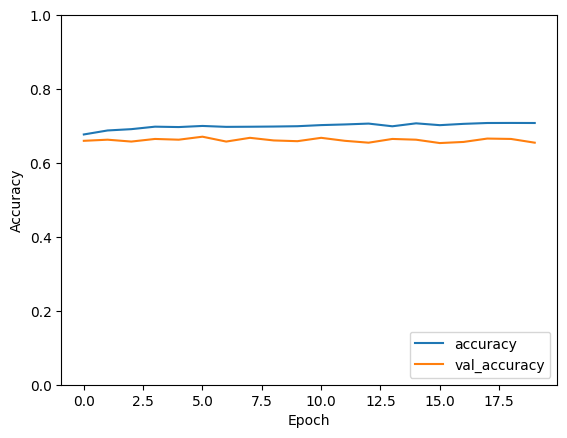

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
print(tf.__version__)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers


def data_preprocessing(df):
    
    col_to_keep = ['death', 'age', 'blood', 'sex', 'temperature', 'heart', 'bp', 'diabetes', 'cancer']
    df = df[col_to_keep]

    df.replace('', 0, inplace=True)
    df.replace({
        'male': 1, 'M': 1, 'Male': 1,
        'female': 0,
        'yes': 1, 'no': 0,
        'metastatic': -1
    }, inplace=True)
    df.fillna(0, inplace=True)
    return df
    
def split_feature_label(df):
    y = df['death']
    X = df.drop(columns=['death'])
    return y, X
    # print(X)
    # print(y)

    # death_0 = y.tolist().count(0)
    # death_1 = y.tolist().count(1)
    # percent_death_0 = 100 * death_0 / (death_0 + death_1)
    # percent_death_1 = 100 * death_1 / (death_0 + death_1)
    # print(f'Survived: {death_0}, or {percent_death_0:.2f}%')
    # print(f'Died: {death_1}, or {percent_death_1:.2f}%')

def standardize(X):
    scaler = StandardScaler()
    X_numeric = scaler.fit_transform(X.select_dtypes(include=['float64']))
    X[X.select_dtypes(include=['float64']).columns] = X_numeric
    return X

def train_model(X, y):
    # Split data into training and validation
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=.3, random_state=42)

    # Define the neural network model
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),  # Input layer
        layers.Dense(128, activation='relu'),     # Hidden layer with 128 neurons and ReLU activation
        layers.Dense(64, activation='relu'),      # Another hidden layer with 64 neurons and ReLU activation
        layers.Dense(1, activation='sigmoid')     # Output layer with sigmoid activation for binary classification
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val))

    # Evaluate the model on the test set
    test_loss, test_accuracy = model.evaluate(X_test, y_test)
    
    model.save('example.h5')
    
    print(f'Test accuracy: {test_accuracy}')

    # Optionally, you can plot training history to visualize model performance
    import matplotlib.pyplot as plt

    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.legend(loc='lower right')
    plt.show()



if __name__ == "__main__":
    data_path = './TD_HOSPITAL_TRAIN.csv'
    df = pd.read_csv(data_path)
    cleaned_data = data_preprocessing(df)
    y, X = split_feature_label(cleaned_data)
    X = standardize(X)
    train_model(X, y)
    